# **Laboratorio 4 - Visión por Computadora**

- Paula Barillas - 22764
- Gerardo Pineda - 22880
- Mónica Salvatierra - 22249

Link del repositorio: https://github.com/alee2602/LAB4-VPC

## **Task 1**



**1. Una homografía 𝐻 es una matriz de 3 × 3. Explique matemáticamente por qué, aunque tiene 9 elementos, solo posee 8 grados de libertad (GDL)**

<img src="img/IMG_3711.jpg" width="800">


- Una homografía H∈R 3×3 tiene 9 parámetros, pero está definida en coordenadas homogéneas. En este espacio, dos matrices que difieren por un factor escalar no nulo representan la misma transformación proyectiva, es decir, H∼αH para cualquier 𝛼≠0. Por esta razón, uno de los 9 parámetros es redundante (la escala global), y por tanto la homografía posee únicamente 8 grados de libertad como tal.

    **1.1. Adicionalmente, respoda. Si tuviéramos una cámara que solo rota sobre su eje óptico (sin traslación ni cambio de perspectiva), ¿la matriz de transformación sigue teniendo 8 GDL o se reduce? Demuestre la estructura de dicha matriz simplificada**

    <img src="img/IMG_3712.jpg" width="800">


- Si la cámara únicamente rota alrededor de su eje óptico y no existe traslación ni cambio de perspectiva, la transformación entre imágenes se reduce a una rotación en el plano. En este caso, la homografía depende únicamente del ángulo de rotación θ. Por lo tanto, los grados de libertad ya no son 8, sino que se reducen a 1, correspondiente al parámetro del ángulo.


**2. En el algoritmo DLT (Direct Linear Transform), convertimos el problema 𝑥′ = 𝐻𝑥 en un sistema de la forma 𝐴ℎ = 0. Explique por qué buscamos el vector singular asociado al menor valor singular de 𝐴 en lugar de simplemente invertir la matriz. ¿Qué representa geométricamente ese "menor valor singular" cuando los datos tienen ruido?**

<img src="img/IMG_3713.jpg" width="800">

<img src="img/IMG_3714.jpg" width="800">

- No se invierte 𝐴 porque el sistema es homogéneo y rectangular, por lo que no es invertible y con ruido solo tendría la solución trivial. Por eso se plantea como un problema de minimización.

- El menor valor singular representa el mínimo error residual posible, indicando qué tan cerca está el sistema de tener una solución exacta y que tan consistentes son los datos.


**3. Si usted selecciona 4 puntos para calcular 𝐻, pero 3 de ellos son colineales (están en la misma línea recta), el algoritmo fallará. Explique algebraicamente qué le sucede a la matriz 𝐴 del sistema DLT en este caso y por qué no tiene solución única.**

- Si tres puntos son colineales, las restricciones que generan en el sistema DLT no son linealmente independientes. Esto provoca que la matriz 𝐴 pierda rango, y por tanto su espacio nulo tenga dimensión mayor a uno. Como consecuencia, existen múltiples soluciones posibles para la homografía y el sistema no tiene una solución única. Esta configuración se considera degenerada para el cálculo de 𝐻.

## **Task 2**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
img1 = cv2.imread("img/DB/1.jpeg")
img2 = cv2.imread("img/DB/2.jpeg")
img3 = cv2.imread("img/DB/3.jpeg")

img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
img3_gray = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

In [3]:
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(img1_gray, None)
kp2, des2 = sift.detectAndCompute(img2_gray, None)

In [4]:
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

## Deteccion

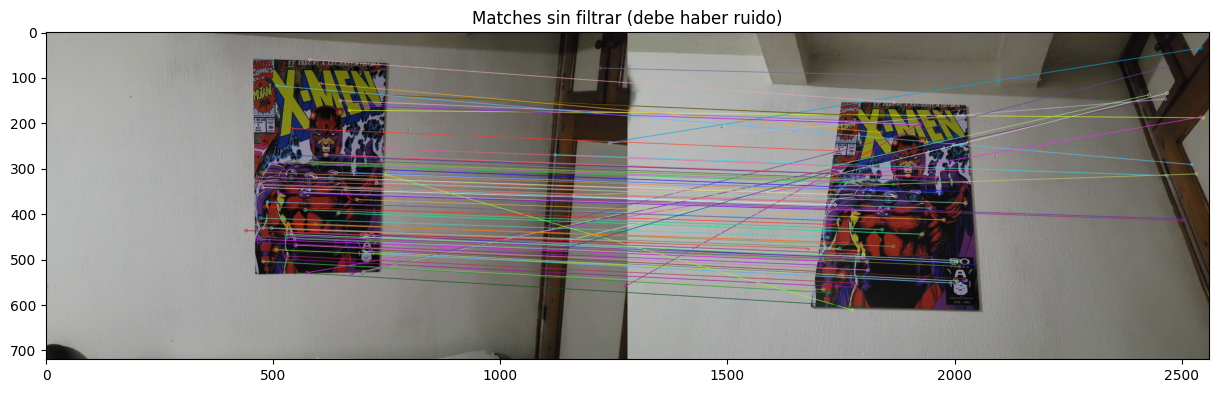

In [5]:
img_matches = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    matches[:100], 
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(15,8))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title("Matches sin filtrar (debe haber ruido)")
plt.show()

## DLT MANUAL

In [6]:
def normalizar_puntos(puntos):
    mean = np.mean(puntos, axis=0)
    std = np.std(puntos)

    T = np.array([
        [1/std, 0, -mean[0]/std],
        [0, 1/std, -mean[1]/std],
        [0, 0, 1]
    ])

    puntos_h = np.hstack((puntos, np.ones((puntos.shape[0],1))))
    puntos_norm = (T @ puntos_h.T).T

    return puntos_norm, T

In [7]:
def calcular_homografia_dlt(puntos_src, puntos_dst):

    src_norm, T_src = normalizar_puntos(puntos_src)
    dst_norm, T_dst = normalizar_puntos(puntos_dst)

    A = []

    for i in range(4):
        x, y, _ = src_norm[i]
        xp, yp, _ = dst_norm[i]

        A.append([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp])
        A.append([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp])

    A = np.array(A)

    # SVD
    U, S, Vt = np.linalg.svd(A)
    H_norm = Vt[-1].reshape(3,3)

    # Desnormalizar
    H = np.linalg.inv(T_dst) @ H_norm @ T_src

    return H / H[2,2]

In [8]:
def ransac_homografia(matches, kp1, kp2, umbral=5, prob_exito=0.99):

    mejor_H = None
    mejor_inliers = []
    max_inliers = 0

    w = 0.5  
    s = 4    

    N = int(np.log(1 - prob_exito) / np.log(1 - w**s))

    for i in range(N):

        sample = random.sample(matches, 4)

        pts_src = np.float32([kp1[m.queryIdx].pt for m in sample])
        pts_dst = np.float32([kp2[m.trainIdx].pt for m in sample])

        H_test = calcular_homografia_dlt(pts_src, pts_dst)

        inliers = []

        for m in matches:
            pt_src = np.array([*kp1[m.queryIdx].pt, 1])
            pt_dst = np.array(kp2[m.trainIdx].pt)

            proyectado = H_test @ pt_src
            proyectado /= proyectado[2]

            error = np.linalg.norm(proyectado[:2] - pt_dst)

            if error < umbral:
                inliers.append(m)

        if len(inliers) > max_inliers:
            max_inliers = len(inliers)
            mejor_inliers = inliers
            mejor_H = H_test

            w = max_inliers / len(matches)
            N = int(np.log(1 - prob_exito) / np.log(1 - w**s))


    if len(mejor_inliers) >= 4:

        pts_src = np.float32([kp1[m.queryIdx].pt for m in mejor_inliers])
        pts_dst = np.float32([kp2[m.trainIdx].pt for m in mejor_inliers])

        A = []
        src_norm, T_src = normalizar_puntos(pts_src)
        dst_norm, T_dst = normalizar_puntos(pts_dst)

        for i in range(len(mejor_inliers)):
            x, y, _ = src_norm[i]
            xp, yp, _ = dst_norm[i]

            A.append([-x, -y, -1, 0, 0, 0, x*xp, y*xp, xp])
            A.append([0, 0, 0, -x, -y, -1, x*yp, y*yp, yp])

        A = np.array(A)

        U, S, Vt = np.linalg.svd(A)
        H_norm = Vt[-1].reshape(3,3)
        mejor_H = np.linalg.inv(T_dst) @ H_norm @ T_src
        mejor_H /= mejor_H[2,2]

    return mejor_H, mejor_inliers

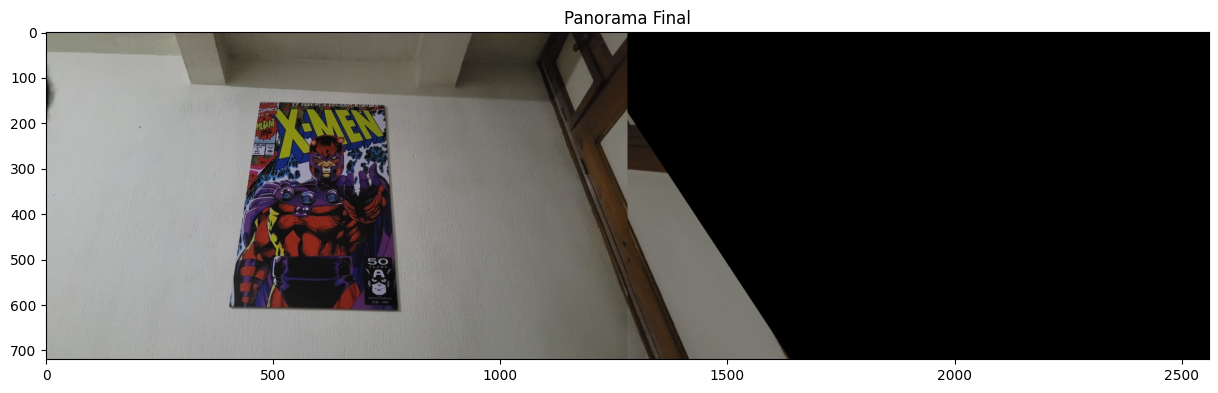

In [9]:
H, inliers = ransac_homografia(matches, kp1, kp2)

altura, ancho = img2.shape[:2]

resultado = cv2.warpPerspective(img1, H, (ancho*2, altura))
resultado[0:altura, 0:ancho] = img2

plt.figure(figsize=(15,8))
plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.title("Panorama Final")
plt.show()

In [10]:
H12, inliers12 = ransac_homografia(matches, kp1, kp2)

h2, w2 = img2.shape[:2]

panorama12 = cv2.warpPerspective(img1, H12, (w2*2, h2))
panorama12[0:h2, 0:w2] = img2

pan_gray = cv2.cvtColor(panorama12, cv2.COLOR_BGR2GRAY)
img3_gray = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

kp_pan, des_pan = sift.detectAndCompute(pan_gray, None)
kp3, des3 = sift.detectAndCompute(img3_gray, None)

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches23 = bf.match(des_pan, des3)
matches23 = sorted(matches23, key=lambda x: x.distance)

In [11]:
H23, inliers23 = ransac_homografia(matches23, kp_pan, kp3)

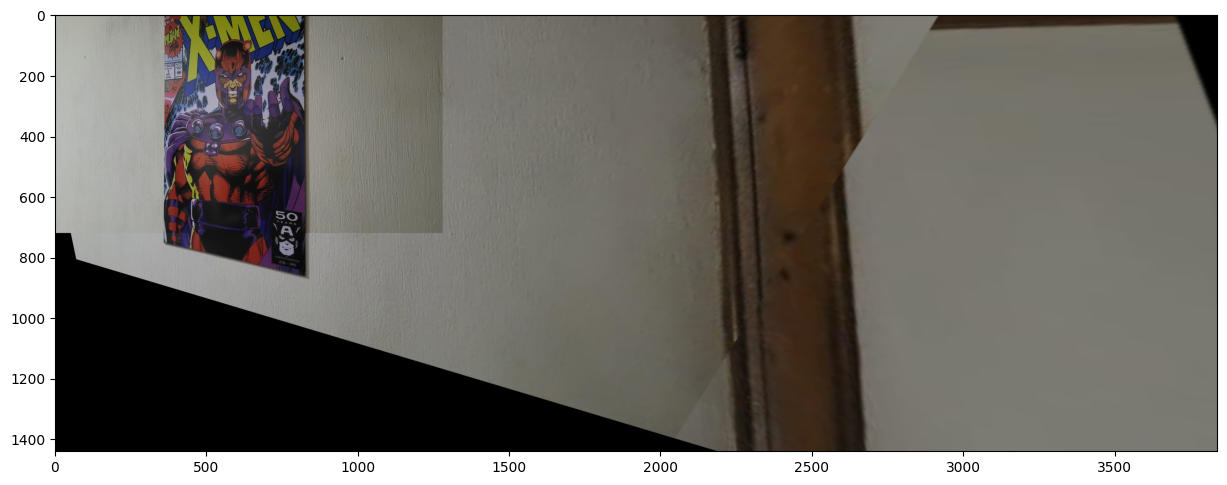

In [12]:
h3, w3 = img3.shape[:2]

panorama_final = cv2.warpPerspective(panorama12, H23, (w3*3, h3*2))
panorama_final[0:h3, 0:w3] = img3

plt.figure(figsize=(15,8))
plt.imshow(cv2.cvtColor(panorama_final, cv2.COLOR_BGR2RGB))
plt.show()

## **Task 3**

Umbral = 0.5 px -> Inliers = 194
Umbral = 1 px -> Inliers = 392
Umbral = 5 px -> Inliers = 548
Umbral = 20 px -> Inliers = 571
Umbral = 50 px -> Inliers = 594


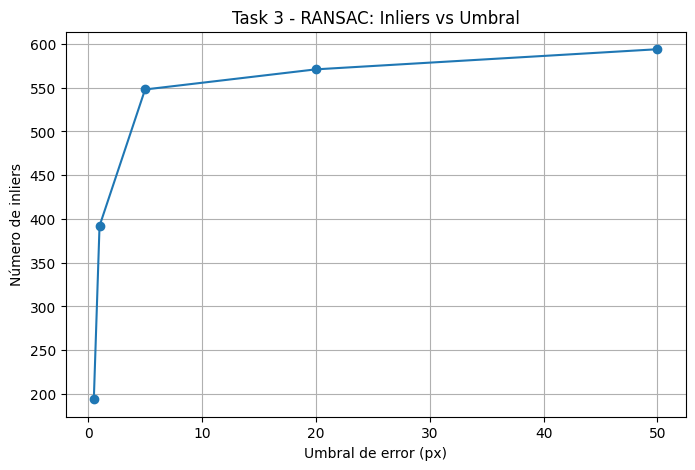

In [13]:
umbrales = [0.5, 1, 5, 20, 50]
num_inliers = []

for u in umbrales:
    H_u, inliers_u = ransac_homografia(matches, kp1, kp2, umbral=u, prob_exito=0.99)
    num_inliers.append(len(inliers_u))
    print(f"Umbral = {u} px -> Inliers = {len(inliers_u)}")

plt.figure(figsize=(8, 5))
plt.plot(umbrales, num_inliers, marker='o')
plt.xlabel('Umbral de error (px)')
plt.ylabel('Número de inliers')
plt.title('Task 3 - RANSAC: Inliers vs Umbral')
plt.grid(True)
plt.show()

***Como ingeniero, ¿qué riesgo corre si establece un umbral demasiado estricto (ej.
0.5px)? ¿Qué pasa con la matriz final si el umbral es muy laxo (ej. 50px)?***

En este caso si se establece un umbral demasiado estricto, en el caso de 0.5 px muchos matches que en realidad son correctos quedan fuera del umbral debido al ruido de medición, iluminación, desenfoque, etc. Por lo cuál hace que RANSAC encuentre muy pocos inliers y la homografía se calcule con muy poca información, volviéndose muy sensible al ruido e inestable. En la gráfica se ve que de 0.5 a 1 px el número de inliers aumenta mucho; en donde pasa de un umbral ultraestricto a uno un poco más permisivo recupera muchos matches buenos. Por otro lado, con un umbral muy laxo como 50 px, un gran porcentaje de todos los matches pasan como inliers, incluyendo muchos "malos". En donde si observamos la gráfica, entre 20 y 50 px casi no aumenta el número de inliers por lo cuál lo que indica que ya estamos aceptando prácticamente todo. En donde si lo vemos desde una perspectiva geométricamente, la homografía H deja de representar bien la transformación del plano ya que empiezan aparecen zonas con ghosting y desalineamientos visibles porque los outliers arrastran la solución.

**Imagine que usted es el Lead Computer Vision Engineer de una empresa de drones. Deben alinear imágenes térmicas de paneles solares tomadas desde el aire para detectar fallos.**

***a. Problema: El drone vuela a 50 metros de altura. El terreno no es perfectamente plano (hay colinas suaves), pero los paneles sí son planos.***

***b. Pregunta A: ¿Es válido usar una Homografía global para unir todo el mapa del terreno? ¿Por qué sí o por qué no?***
Consideramos que no sería válido, debido a que para que sea válido todos los puntos deben estar en un mismo plano fisico. Ahora bien, considerando que hay colinas a pesar de ser suaves y bien los paneles si son planos, los puntos a distintas distancias se mueven de forma diferente entre imágenes donde en una sola matriz H no se puede llegar“aplanar” correctamente zonas con profundidades diferentes al mismo tiempo ya que  siempre habrán regiones que queden deformadas o mal alineadas. Por lo cuál consideramso que lo ideal es usar homografías locales, por cada panel o región casi plan o ya más profesional pasar esto a un modelo 3D si queremos mapear todo el terreno.


***Pregunta B: Su algoritmo RANSAC está tardando demasiado (3 segundos por frame) en la computadora a bordo del drone (Raspberry Pi). La telemetría indica que el 90% de los matches iniciales son outliers debido al pasto y árboles repetitivos. i. Proponga una estrategia concreta para reducir el tiempo de ejecución sin cambiar el hardware. (Pista: Piense en la fórmula de N o en pre-filtrado geométrico)***

En este caso se podría usar un  ratio test de Lowe para comparar el mejor y el segundo mejor match y de esta forma poder descartar matches ambiguos.Como también establecer un  umbral fuerte a la distancia del descriptor y quedarse solo con los mejores N matches. Y bueno como en teoria sabemos dónde deberían estar los paneles, se podría crear una máscara y descartar todos los keypoints que caen fuera de esas regiones (como el pasto y árboles). Así, la mayoría de los matches que sobreviven pertenecen a paneles y aumentaria w. Y por últimp, bajariamos ligeramente la probabilidad de éxito (p), por ejemplo de 0.99 a 0.95, para reducir aún más (N) y tener un número de iteraciónes que ocupen 5 segundos. Con esto, consideramos que se llegue a reducir significativamente el número de iteraciones y de tiempo.


## **Prompt Utilizado**

**Uso de ChatGPT**


**Task 2**

En la segunda tarea usamos ChatGPT como guía para entender paso a paso que necesitaba el algoritmo RANSAC. Le preguntamos como es que funciona y se implementaria de forma manual, donde nos dio una guia de los calculos que habia que tomar en cuenta. Tambien, le pregutamos porque se miraba de cierta formas la imagen porque no nos hacia sentido y les compartimos el codigo, donde nos ayudo a refinar los erroes que teniamos. Para referencia de esta imagen enviada a chat es la segunfa imagen pero con todo negro